# **APE 11 —  Inferencia Estadística Multigrupo: Análisis de Varianza (ANOVA de 1 factor) y Pruebas Post-Hoc (Tukey)**

## Teoría de la Distribución y Probabilidad | Ingeniería en Computación
**Estudiante:**
- Dario Xavier Chillogallo Chamba
- Michael Carbay
- Jose Maldonado
- Paolo Merino
- Freddy Ordoñez

**Grupo:** "C"  

**Docente:** Ing. Cristian Narvaez  


**Dataset:** ENEMDU — Índice de Confianza al Consumidor | Febrero 2026 | Región Loja

In [1]:
# ============================================================
# BLOQUE 1: CARGA Y PREPARACIÓN DEL DATASET
# ============================================================

import pandas as pd

# Cargamos el dataset ENEMDU (separador ; y decimales con coma, formato Ecuador)
df = pd.read_csv('/content/drive/MyDrive/enemdu_consumidor_2026_01 (1).csv', sep=';', decimal=',')

# Renombramos variables clave para legibilidad
df.rename(columns={
    'area' : 'zona',
    'fexp' : 'fexp',
    'c01'  : 'sit_econ_hogar',
    'c18'  : 'sit_econ_pais',
    'c02'  : 'expectativa_hogar'
}, inplace=True)


# Etiquetas legibles
df['zona_label'] = df['zona'].map({1: 'Urbano', 2: 'Rural'})
df['sit_econ_hogar_label'] = df['sit_econ_hogar'].map({1:'Mejor', 2:'Igual', 3:'Peor'})

print(f'Registros totales : {df.shape[0]:,}')
print(f'Variables         : {df.shape[1]}')
print(f'Distribucion por zona:')
print(df['zona_label'].value_counts())
print(f'Estadisticas de fexp:')
print(df['fexp'].describe().round(2))

Registros totales : 8,791
Variables         : 30
Distribucion por zona:
zona_label
Urbano    6523
Rural     2268
Name: count, dtype: int64
Estadisticas de fexp:
count     8791.00
mean       599.37
std       1238.48
min          3.78
25%         92.41
50%        244.29
75%        563.98
max      18136.57
Name: fexp, dtype: float64


---
# **Tarea 1:**
## **Análisis de Varianza (ANOVA de 1 factor)**
El ANOVA compara la varianza entre los grupos frente a la varianza dentro de los grupos.
•	H0: Todas las medias poblacionales son iguales.
•	H1: Al menos una media poblacional es diferente.


In [2]:
#Ejemplo:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Ejemplo: Tiempos de respuesta (ping) de 3 algoritmos
np.random.seed(42)
grupo_A = np.random.normal(loc=45.0, scale=5.0, size=30)
grupo_B = np.random.normal(loc=46.5, scale=4.8, size=30)
grupo_C = np.random.normal(loc=52.0, scale=5.5, size=30)

stat_f, p_val_f = f_oneway(grupo_A, grupo_B, grupo_C)
print(f"Estadístico F: {stat_f:.4f} | Valor-p: {p_val_f:.4e}")


Estadístico F: 22.6087 | Valor-p: 1.2389e-08


---
---
# **Tarea 2:**
## **Hito del Proyecto - Segmentación Multigrupo**
1.	**Importe su dataset regional.**
2.	**Identifique una variable categórica con al menos 3 niveles (ej. tipo de conexión, meses, sectores).**

**2.1: Variable elegida:** c01  

 Esta variable pregunta: "Con relación al mes anterior, ¿la situación económica de su hogar es:" y ofrece 3 niveles:
- 1: Mejor.
- 2: Igual.
- 3: Peor.


3.	**Ejecute f_oneway y redacte un dictamen técnico: ¿El ANOVA sugiere que existen diferencias significativas entre los niveles? ¿Es necesario investigar más a fondo?**

**Hipotesis nula (HO):**  
- Las medias de la variable fexp (factor de expansión) son iguales para los tres niveles de sit_econ_hogar (situación económica del hogar: 'Mejor', 'Igual' y 'Peor').  
**Hipótesis Alternativa (H1):**  
- Al menos una de las medias de la variable fexp es diferente entre los tres niveles de sit_econ_hogar

In [5]:
#El siguiente código separa los datos en tres grupos según su respuesta en c01 y aplica la función f_oneway de scipy.stats.
import pandas as pd
from scipy import stats

# Limpieza: Asegurar que fexp sea numérico y eliminar nulos
df['fexp'] = pd.to_numeric(df['fexp'], errors='coerce')
df = df.dropna(subset=['fexp', 'sit_econ_hogar'])

# 2. Segmentación de grupos basados en sit_econ_hogar
grupo_mejor = df[df['sit_econ_hogar'] == 1]['fexp']
grupo_igual = df[df['sit_econ_hogar'] == 2]['fexp']
grupo_peor  = df[df['sit_econ_hogar'] == 3]['fexp']

# 3. Ejecución de ANOVA de un factor (f_oneway)
f_stat, p_value = stats.f_oneway(grupo_mejor, grupo_igual, grupo_peor)

print(f"Estadístico F: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")

# Dictamen técnico automático
if p_value < 0.05:
    print("Dictamen: Existen diferencias significativas entre los niveles.")
else:
    print("Dictamen: No se encontraron diferencias significativas.")

Estadístico F: 1.5594
p-value: 2.1031e-01
Dictamen: No se encontraron diferencias significativas.


### **Interpretacion:**
- No se descarta HO, no hay evidencia estadistica suficiente para concluir que existen diferencias significativas en las medias de la variable fexp en los grupos "mejor", "peor" e "igual"   

**¿El ANOVA sugiere que existen diferencias significativas entre los niveles?**  
 - No. El valor p (p-value = 0.2103) es mayor que el nivel de significancia común (0.05).
 - Esto significa que no hay evidencia estadística suficiente para rechazar la hipótesis nula, la cual establece que las medias de la variable 'fexp' son iguales en los tres niveles de 'sit_econ_hogar'.

**¿Es necesario investigar más a fondo?**  
 - En el contexto de un ANOVA que no encuentra diferencias significativas
 - no es necesario proceder con pruebas post-hoc (como Tukey) para identificar qué grupos específicos difieren, ya que el ANOVA ya ha indicado que no hay una diferencia general entre los grupos.
 - Sin embargo, si el resultado no cumple con las expectativas o se desea entender más a fondo la distribución de los datos dentro de cada grupo, se podrían explorar estadísticas descriptivas adicionales o visualizaciones para cada nivel de 'sit_econ_hogar'
 - El punto anterior no sería para una inferencia estadística de diferencias entre grupos en este caso.


---
---
# **Tarea 3:**
## **Pruebas Post-hoc (Tukey HSD)**

Si el ANOVA rechaza H0, debemos identificar qué pares difieren.
from statsmodels.stats.multicomp import pairwise_tukeyhsd

**NOTA:** Apesar de que no rechazamos H0, se procede con las pruebas turkey por temas educativos y de indole del APE presente

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
 igual  mejor   90.657 0.2683  -46.5651  227.879  False
 igual   peor  33.6668 0.5539  -42.4885 109.8221  False
 mejor   peor -56.9902   0.64 -205.3464   91.366  False
-------------------------------------------------------


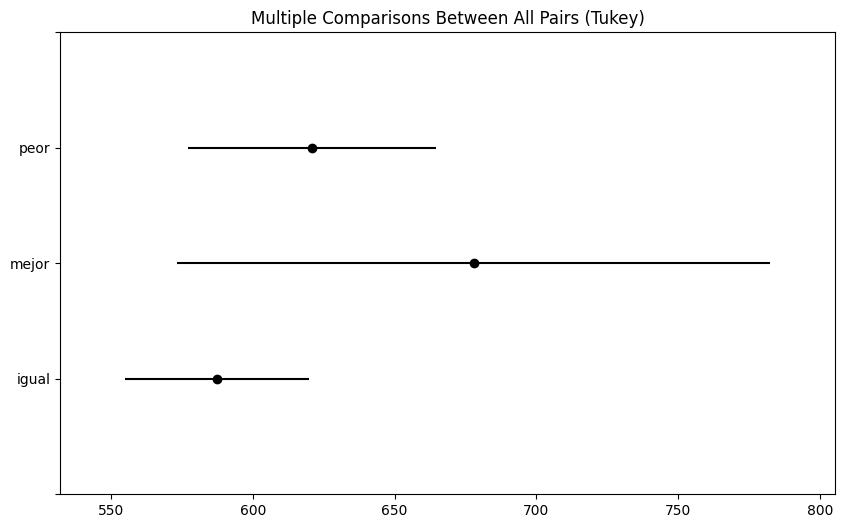

In [10]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preparación de datos
datos_combinados = pd.DataFrame({'Valor': np.concatenate([grupo_mejor, grupo_igual, grupo_peor]),
                                 'Grupo': ['mejor']*len(grupo_mejor) + ['igual']*len(grupo_igual) + ['peor']*len(grupo_peor)})

tukey = pairwise_tukeyhsd(endog=datos_combinados['Valor'],
                          groups=datos_combinados['Grupo'],
                          alpha=0.05)
print(tukey)
tukey.plot_simultaneous()
plt.show()

**Explicacion:**  

Ninguno de los 3 grupos de comparacion muestra una diferencia estadistica significante

---
---
**DECLARACION DE USO DE IA:**  

Para el presente se uso la IA generativa "Gemini" que esta integrada en el entorno Colab, sin embargo, esta no nos proporciona un link con acceso al chat, por ende, se copiara textualmente el chat con la IA "Gemini"

---
- **Prompt:**Please explain this error:keyError: ["c01"]

- **Answer:***The error 'KeyError: ['c01']' indicates that the column 'c01' is not present in your DataFrame. In an earlier step, 'c01' was renamed to 'sit_econ_hogar'. You need to use 'sit_econ_hogar' instead of 'c01' in your code.
---

---
- **prompt:** based in the results of the execution, answer these questions, (answer in spanish, please): : ¿El ANOVA sugiere que existen diferencias significativas entre los niveles? ¿Es necesario investigar más a fondo?
Basado en los resultados de la ejecución del ANOVA:

- **answer** ¿El ANOVA sugiere que existen diferencias significativas entre los niveles? No. El valor p (p-value = 0.2103) es mayor que el nivel de significancia común (por ejemplo, 0.05). Esto significa que no hay evidencia estadística suficiente para rechazar la hipótesis nula, la cual establece que las medias de la variable 'fexp' son iguales en los tres niveles de 'sit_econ_hogar'.

- ¿Es necesario investigar más a fondo? En el contexto de un ANOVA que no encuentra diferencias significativas, no es necesario proceder con pruebas post-hoc (como Tukey) para identificar qué grupos específicos difieren, ya que el ANOVA ya ha indicado que no hay una diferencia general entre los grupos. Sin embargo, si el resultado no cumple con las expectativas o se desea entender más a fondo la distribución de los datos dentro de cada grupo, se podrían explorar estadísticas descriptivas adicionales o visualizaciones para cada nivel de 'sit_econ_hogar', aunque no sería para una inferencia estadística de diferencias entre grupos en este caso
---

- **prompt:** next question is: Tarea 3: Pruebas Post-hoc (Tukey HSD)  But, I don´t decline HO, I can do something else whit thatr code? or not}  

- **answer:** Tienes razón, como el ANOVA no rechazó la Hipótesis Nula (H0), generalmente no es estadísticamente apropiado proceder con las pruebas post-hoc de Tukey HSD para los grupos de sit_econ_hogar.

---
- **prompt:** Please explain this error: "valueerror: All arrays must be of the same lenght"  

- **answer:** The error ValueError: All arrays must be of the same length is happening because the Grupo column you are trying to create has a fixed length of 90 (30 for each category), but the Valor column (which concatenates grupo_mejor, grupo_igual, and grupo_peor) has a total length of 8791. To fix this, you need to make sure the number of labels in the Grupo column matches the actual number of elements in each grupo.

- You're getting a NameError because the pairwise_tukeyhsd function hasn't been imported into the execution environment. Even though it's mentioned in a text cell, Python needs to see the import statement in a code cell to make the function available. I'll add the necessary import to the current cell.

- The Tukey HSD post-hoc test has been executed. As anticipated from the ANOVA results, which indicated no significant overall difference between groups, the Tukey HSD test confirms this finding for all pairwise comparisons.
---